📌 1. Import Library

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, recall_score
from imblearn.over_sampling import SMOTE
import joblib


📌 2. Load Dataset Mentah

In [118]:
df = pd.read_csv('dataset/diabetes_prediction_dataset.csv')
df.head()


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


📊 3. Eksplorasi Awal & Visualisasi Sebelum Cleaning

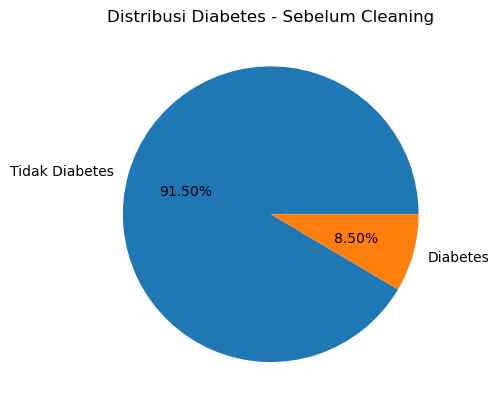

In [119]:
plt.pie(df['diabetes'].value_counts(), labels=['Tidak Diabetes', 'Diabetes'], autopct='%1.2f%%')
plt.title("Distribusi Diabetes - Sebelum Cleaning")
plt.show()

🔍 Cek missing values


In [120]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

🧾 Duplicate Data

In [121]:
df.duplicated().sum()

np.int64(3854)

🧹 4. Data Cleaning & Encoding

In [122]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()


np.int64(0)

In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96146 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               96146 non-null  object 
 1   age                  96146 non-null  float64
 2   hypertension         96146 non-null  int64  
 3   heart_disease        96146 non-null  int64  
 4   smoking_history      96146 non-null  object 
 5   bmi                  96146 non-null  float64
 6   HbA1c_level          96146 non-null  float64
 7   blood_glucose_level  96146 non-null  int64  
 8   diabetes             96146 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 7.3+ MB


📊 5. Visualisasi Setelah Pembersihan

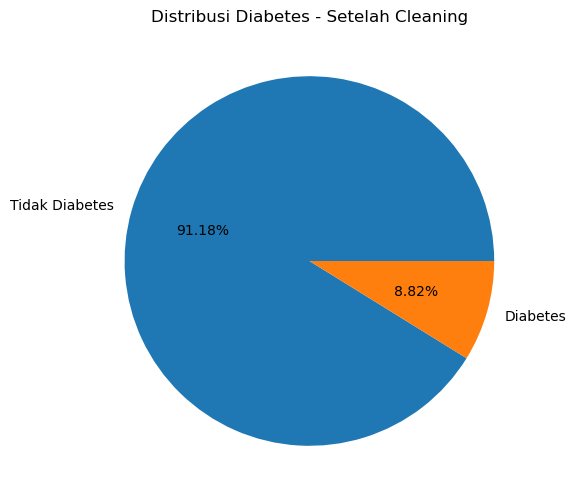

In [124]:
plt.figure(figsize=(6, 6))
plt.pie(df['diabetes'].value_counts(), labels=['Tidak Diabetes', 'Diabetes'], autopct='%1.2f%%')
plt.title("Distribusi Diabetes - Setelah Cleaning")
plt.show()

📊 EXPLANATORY DATA ANALYSIS

Jumlah data yang memiliki diabetes: 8482


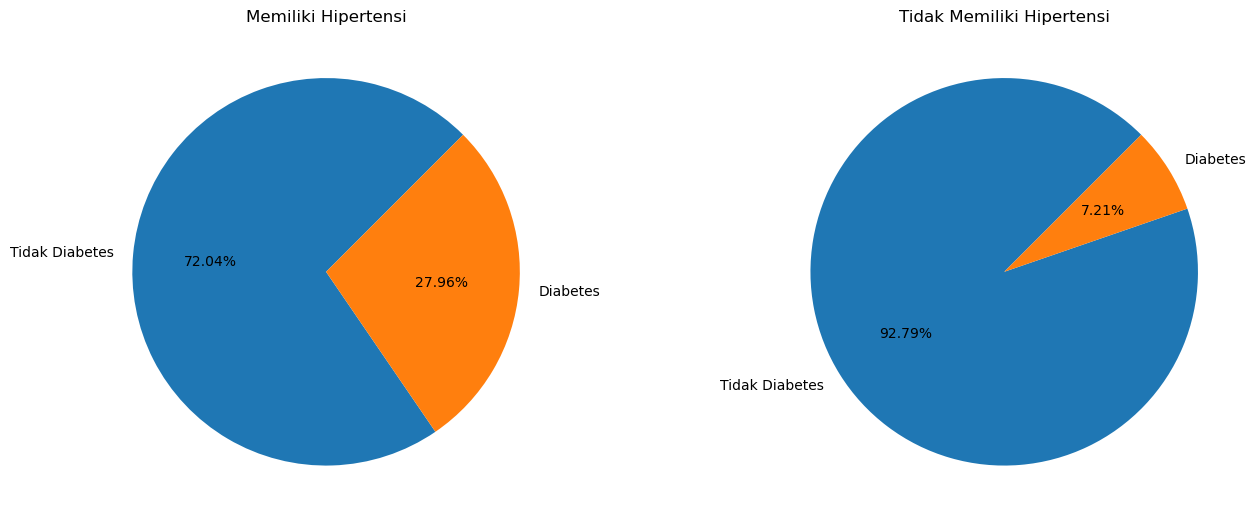

In [125]:
print("Jumlah data yang memiliki diabetes:", df[df['diabetes'] == 1].shape[0])
plt.figure(figsize = [15,15])

plt.subplot(1,2,1)
plt.pie(df[df['hypertension'] == 1]['diabetes'].value_counts().values, labels=['Tidak Diabetes', 'Diabetes'], autopct='%1.2f%%', startangle=45)
plt.title('Memiliki Hipertensi')


plt.subplot(1,2,2)
plt.pie(df[df['hypertension'] == 0]['diabetes'].value_counts().values, labels=['Tidak Diabetes', 'Diabetes'], autopct='%1.2f%%', startangle=45)
plt.title("Tidak Memiliki Hipertensi")

plt.subplots_adjust(wspace=0.4)
plt.show()

Jumlah data yang memiliki hipertensi: 7461


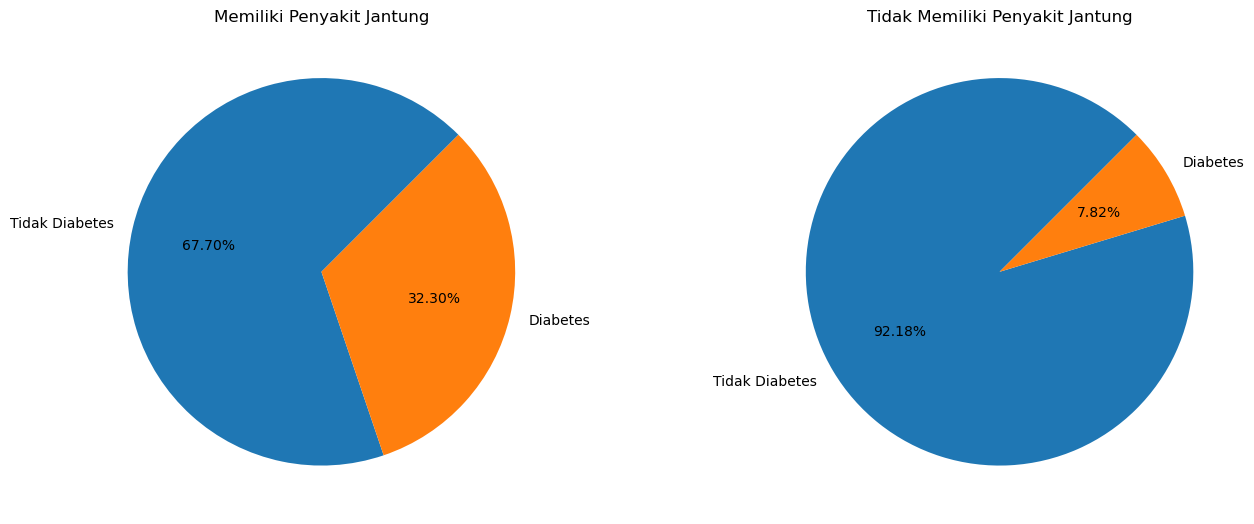

In [126]:
print("Jumlah data yang memiliki hipertensi:", df[df['hypertension'] == 1].shape[0])
plt.figure(figsize = [15,15])

plt.subplot(1,2,1)
plt.pie(df[df['heart_disease'] == 1]['diabetes'].value_counts().values, labels=['Tidak Diabetes', 'Diabetes'], autopct='%1.2f%%', startangle=45)
plt.title('Memiliki Penyakit Jantung')


plt.subplot(1,2,2)
plt.pie(df[df['heart_disease'] == 0]['diabetes'].value_counts().values, labels=['Tidak Diabetes', 'Diabetes'], autopct='%1.2f%%', startangle=45)
plt.title("Tidak Memiliki Penyakit Jantung")

plt.subplots_adjust(wspace=0.4)
plt.show()

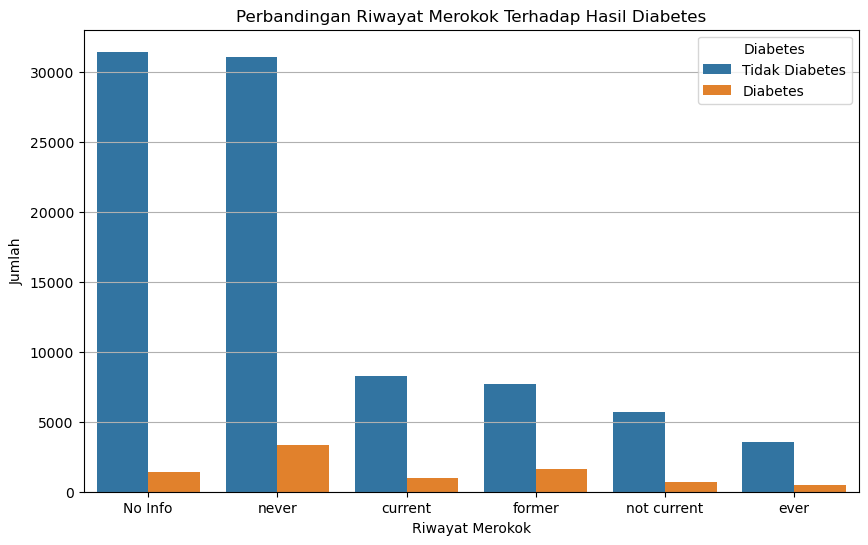

In [127]:
non_diabetes_counts = df[df['diabetes'] == 0]['smoking_history'].value_counts()
sorted_categories = non_diabetes_counts.index

plt.figure(figsize=(10, 6))
sns.countplot(
    x='smoking_history',
    hue='diabetes',
    data=df,
    order=sorted_categories)
plt.title('Perbandingan Riwayat Merokok Terhadap Hasil Diabetes')
plt.xlabel('Riwayat Merokok')
plt.ylabel('Jumlah')
plt.legend(title='Diabetes', loc='upper right', labels=['Tidak Diabetes', 'Diabetes'])
plt.grid(axis='y')
plt.show()

In [128]:
tipe_bmi = []

for tipe in df['bmi']:
    if tipe <= 18.5:
        tipe_bmi.append('underweight')
    elif(tipe > 18.5 and tipe <= 24.9):
        tipe_bmi.append('normal')
    elif(tipe > 24.9 and tipe <=29.9):
        tipe_bmi.append('overweight')
    else :
        tipe_bmi.append('obesity')

df['tipe_bmi'] = tipe_bmi

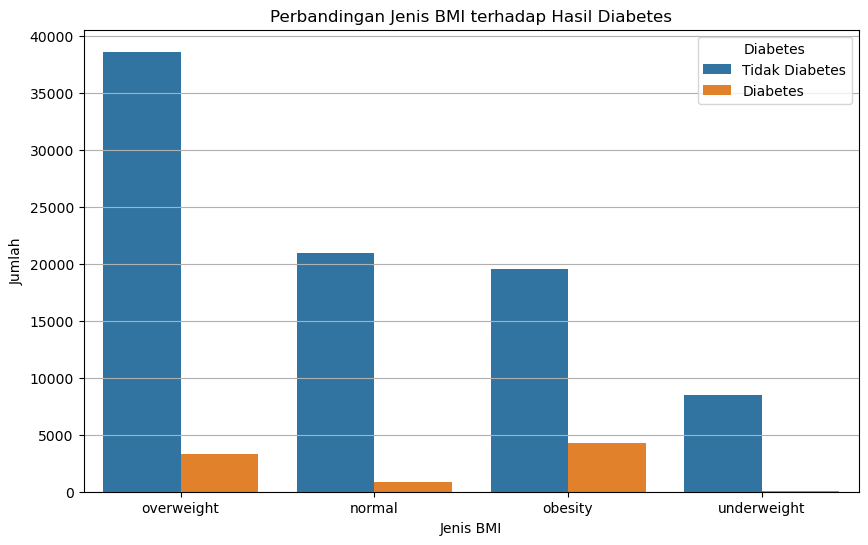

In [129]:
plt.figure(figsize=(10, 6))
sns.countplot(
    x='tipe_bmi',
    hue='diabetes',
    data=df)
plt.title('Perbandingan Jenis BMI terhadap Hasil Diabetes')
plt.xlabel('Jenis BMI')
plt.ylabel('Jumlah')
plt.legend(title='Diabetes', loc='upper right', labels=['Tidak Diabetes', 'Diabetes'])
plt.grid(axis='y')
plt.show()

In [130]:
blood_glucose = []

for level in df['blood_glucose_level']:
    if level <= 99:
        blood_glucose.append('normal')
    elif (level > 99) and (level <=125):
        blood_glucose.append('prediabetes')
    else :
        blood_glucose.append('diabetes')

df['blood_glucose_test'] = blood_glucose

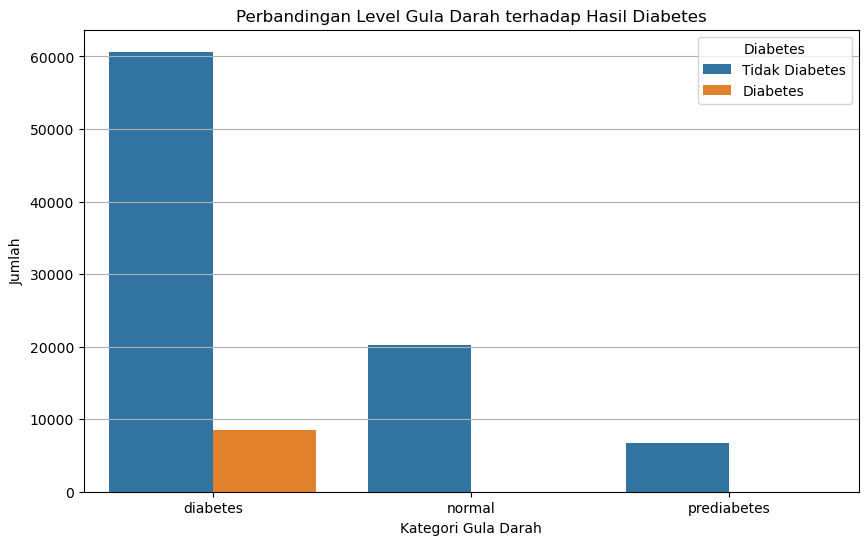

In [131]:
plt.figure(figsize=(10, 6))
sns.countplot(
    x='blood_glucose_test',
    hue='diabetes',
    data=df
)
plt.title('Perbandingan Level Gula Darah terhadap Hasil Diabetes')
plt.xlabel('Kategori Gula Darah')
plt.ylabel('Jumlah')
plt.legend(title='Diabetes', loc='upper right', labels=['Tidak Diabetes', 'Diabetes'])
plt.grid(axis='y')
plt.show()


In [132]:
df.drop(columns='tipe_bmi', inplace=True)

In [133]:
df.drop(columns='blood_glucose_test', inplace=True)

Data Cleaning & Encoding

In [134]:
df = df.dropna()  # hapus missing values jika ada

# Encode kolom kategorikal
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df['smoking_history'] = le.fit_transform(df['smoking_history'])

🧪 6. Split Feature & Target

In [135]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']

🧪 9. Train Test Split

In [136]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

🧼 7. Feature Scaling

In [137]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

📈 8. SMOTE Oversampling

In [138]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

📊 Pie Chart Setelah SMOTE

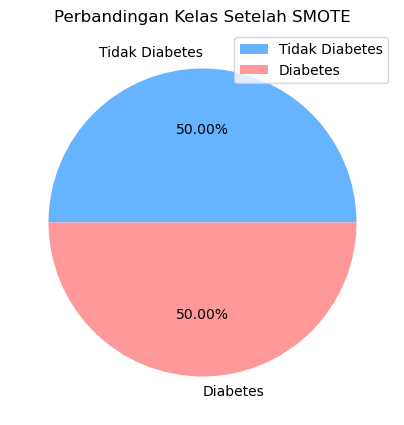

In [139]:
plt.figure(figsize=(5, 5))
plt.pie(pd.Series(y_resampled).value_counts().values, labels=['Tidak Diabetes', 'Diabetes'], autopct='%1.2f%%', colors=['#66b3ff','#ff9999'])
plt.title('Perbandingan Kelas Setelah SMOTE')
plt.legend()
plt.show()

🤖 10. Training SVM

In [ ]:
classifier = SVC(kernel='linear', random_state=42)
classifier.fit(X_train, y_train)

🧾 11. Evaluasi

=== Evaluasi SVM dengan SMOTE ===
Train Accuracy: 0.8946257717699734
Test Accuracy: 0.8931443563565847
F1 Score: 0.895478256018299
Recall: 0.91547367820681
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.87      0.89     17533
           1       0.88      0.92      0.90     17533

    accuracy                           0.89     35066
   macro avg       0.89      0.89      0.89     35066
weighted avg       0.89      0.89      0.89     35066



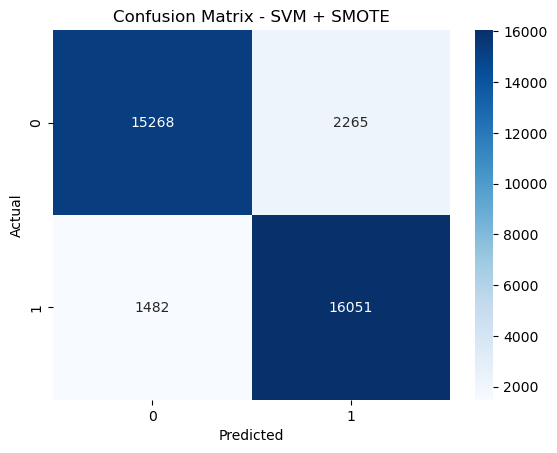

In [ ]:
y_train_pred = classifier.predict(X_train)
y_test_pred = classifier.predict(X_test)

print("=== Evaluasi SVM dengan SMOTE ===")

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

print("F1 Score:", f1_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - SVM + SMOTE")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


📉 12. Learning Curve

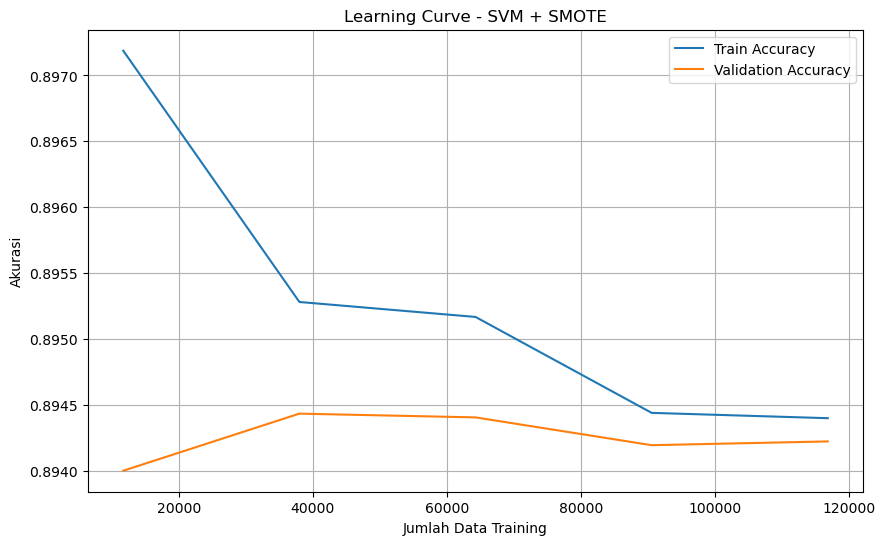

In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    classifier, X_resampled, y_resampled,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    shuffle=True,
    random_state=42
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Train Accuracy')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Validation Accuracy')
plt.title('Learning Curve - SVM + SMOTE')
plt.xlabel('Jumlah Data Training')
plt.ylabel('Akurasi')
plt.legend()
plt.grid()
plt.show()


💾 13. Save Model & Scaler

In [ ]:
joblib.dump(classifier, 'model/diabetes_model_svm_smote.sav')
joblib.dump(scaler, 'model/scaler_svm_smote.sav')


['model/scaler_svm_smote.sav']

💾 14. Simpan Dataset Setelah Cleaning

In [ ]:
# Simpan dataset bersih
df_clean = df.copy()
df_clean.to_csv('dashboard/diabetes_dataset_clean.csv', index=False)
print("✅ Dataset clean berhasil disimpan di: dashboard/diabetes_dataset_clean.csv")


✅ Dataset clean berhasil disimpan di: dashboard/diabetes_dataset_clean.csv


📌 Diagram Korelasi

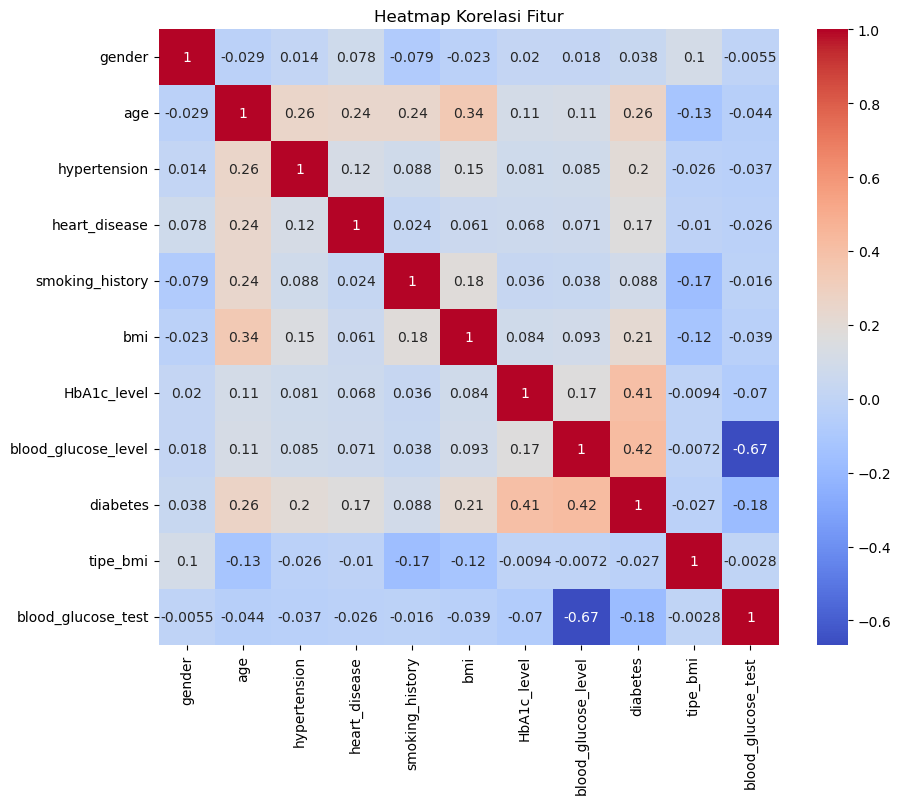

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Heatmap Korelasi Fitur")
plt.show()
